## import package

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
import sys


In [ ]:
sys.path.append('/content/drive/MyDrive/Research/0-Xiayin_research/4_GeoCP_with_geosimilarity/GeoConformal')

import GeoConformalSpatialRegression

In [ ]:
import GeoSIMCPzhao

In [ ]:
!pip install xgboost geopandas geoplot contextily

In [ ]:
import xgboost as xgb
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geoplot as gplt
import geoplot.crs as gcrs
from sklearn.model_selection import train_test_split
import contextily as cx

## Load data

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Research/0-Xiayin_research/4_GeoCP_with_geosimilarity//data//us_life_expectancy.csv')
data = data.dropna(subset=['ratio', 'Diversity', 'Asianalon', 'NativeHaw', 'TwoorMor', 'Hispanico', 'Whitealon'])

features = data[['ratio', 'Diversity', 'Asianalon', 'NativeHaw', 'TwoorMor', 'Hispanico', 'Whitealon']]
loc = data[['lon', 'lat']]

In [ ]:
data

,cartodb_id,countyfp,statefp,statename,countyname,countyfips,tractname,ratio,statemhir,tractmhir,...,BlackorA,AmericanI,Asianalon,NativeHaw,TwoorMor,Hispanico,Whitealon,county,lon,lat
0,80,57,12,Florida,"Hillsborough County, Florida",12057,"Census Tract 108.14, Hillsborough County, Florida",0.575,47212,27143,...,17.4,0.5,3.9,0.1,2.5,26.0,52.3,County,-82.430705,27.873952
1,398,213,48,Texas,"Henderson County, Texas",48213,"Census Tract 9509.01, Henderson County, Texas",0.752,52576,39558,...,6.6,0.8,0.6,0.1,1.6,11.8,79.4,County,-95.853592,32.211895
2,409,409,48,Texas,"San Patricio County, Texas",48409,"Census Tract 102.01, San Patricio County, Texas",0.708,52576,37231,...,2.1,0.9,1.1,0.1,1.4,55.4,40.8,County,-97.244675,27.859829
3,647,5,24,Maryland,"Baltimore County, Maryland",24005,"Census Tract 4209, Baltimore County, Maryland",0.485,74149,35996,...,27.5,0.4,5.7,0.1,2.3,4.8,60.5,County,-76.640195,39.463417
4,712,31,13,Georgia,"Bulloch County, Georgia",13031,"Census Tract 1104.03, Bulloch County, Georgia",0.367,49342,18103,...,28.9,0.4,1.6,0.1,1.6,3.6,64.6,County,-81.743179,32.396803
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3979,4637,101,54,West Virginia,"Webster County, West Virginia",54101,"Census Tract 9701, Webster County, West Virginia",0.683,41576,28416,...,0.4,0.1,0.3,0.0,1.1,0.4,97.7,County,-80.421865,38.494706
3980,4638,103,55,Wisconsin,"Richland County, Wisconsin",55103,"Census Tract 9702, Richland County, Wisconsin",1.033,52738,54477,...,0.6,0.4,0.6,0.0,0.9,2.2,95.4,County,-90.429483,43.375636
3981,4639,21,8,Colorado,"Conejos County, Colorado",8021,"Census Tract 9748, Conejos County, Colorado",0.538,59448,31957,...,0.6,3.5,0.7,0.2,2.2,53.9,43.6,County,-106.191603,37.200716
3982,4640,47,16,Idaho,"Gooding County, Idaho",16047,"Census Tract 9602, Gooding County, Idaho",0.893,47334,42285,...,0.5,1.8,0.8,0.2,1.8,28.8,68.5,County,-114.811564,42.970922


In [ ]:
y = data['le_racea_4']
X_aspatial = data[['ratio', 'Diversity', 'Asianalon', 'NativeHaw', 'TwoorMor', 'Hispanico', 'Whitealon']]
X_spatial = data[['ratio', 'Diversity', 'Asianalon', 'NativeHaw', 'TwoorMor', 'Hispanico', 'Whitealon', 'lat','lon']]

## train prediction model and output uncertainty with GeCP

In [ ]:
X_aspatial_train, X_apsatial_temp, X_spatial_train, X_spatial_temp, y_train, y_temp, loc_train, loc_temp = train_test_split(X_aspatial, X_spatial, y, loc, train_size=0.8, random_state=42)
X_aspatial_val, X_aspatial_test, X_spatial_val, X_spatial_test, y_val, y_test, loc_val, loc_test = train_test_split(X_apsatial_temp, X_spatial_temp, y_temp, loc_temp, train_size=0.5, random_state=42)

In [ ]:
model_spatial = xgb.XGBRegressor(n_estimators=500, max_depth=3, min_child_weight=1.0, colsample_bytree=1.0)

In [ ]:
model_spatial.fit(X_spatial_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=1.0, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

### GeoCP

In [ ]:
## GeoCP
from GeoConformalSpatialRegression import GeoConformalSpatialRegression

geocp_spatial = GeoConformalSpatialRegression(predict_f=model_spatial.predict, nonconformity_score_f=None, miscoverage_level=0.1, bandwidth=3, coord_calib=loc_val.values, coord_test=loc_test.values, X_calib=X_spatial_val, y_calib=y_val, X_test=X_spatial_test, y_test=y_test)

In [ ]:
results = geocp_spatial.analyze()


In [ ]:
results.uncertainty

np.float64(50.45374336242676)

In [ ]:
results.coverage_probability

np.float64(0.9348370927318296)

### GeoSIMCP

In [ ]:
## GeoCP
from GeoSIMCP import GeoSIMConformalSpatialRegression

#X_spatial_val = X_spatial_val.astype(float)
#X_spatial_test = X_spatial_test.astype(float)


geosimcp = GeoSIMConformalSpatialRegression(
    predict_f=model_spatial.predict,            # 原模型，含地理特征
    miscoverage_level=0.1,
    bandwidth=3,
    coord_calib=loc_val.values,
    coord_test=loc_test.values,
    X_calib=X_spatial_val,                          # 包含经纬度特征
    y_calib=y_val,
    X_test=X_spatial_test,                          # 包含经纬度特征
    y_test=y_test,
    X_calib_weight=X_aspatial_val,              # 💡 纯特征向量，不含经纬度
    X_test_weight=X_aspatial_test,
    lambda_weight=0.5
)

results_geosimcp = geosimcp.analyze()
print("Coverage:", results_geosimcp.coverage_probability)
print("Uncertainty:", results_geosimcp.uncertainty)


Coverage: 0.9398496240601504
Uncertainty: 48.57947894728276


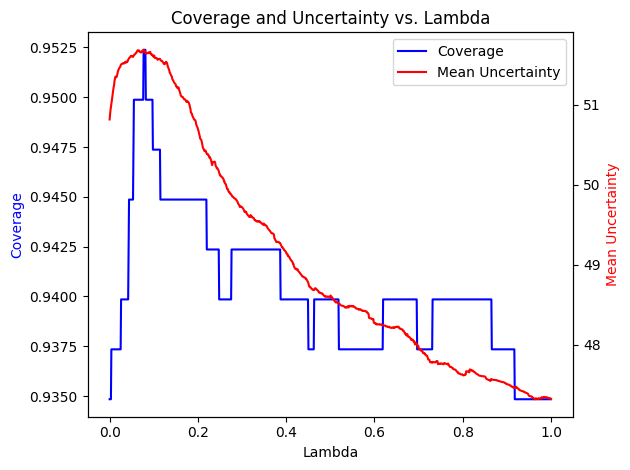

In [ ]:
lambda_list = np.linspace(0, 1, 1000)
coverage_list = []
uncertainty_list = []

for lam in lambda_list:
    geosimcp = GeoSIMConformalSpatialRegression(
      predict_f=model_spatial.predict,            # 原模型，含地理特征
      miscoverage_level=0.1,
      bandwidth=3,
      coord_calib=loc_val.values,
      coord_test=loc_test.values,
      X_calib=X_spatial_val,                          # 包含经纬度特征
      y_calib=y_val,
      X_test=X_spatial_test,                          # 包含经纬度特征
      y_test=y_test,
      X_calib_weight=X_aspatial_val,              # 💡 纯特征向量，不含经纬度
      X_test_weight=X_aspatial_test,
      lambda_weight=lam
  )
    result = geosimcp.analyze()
    coverage_list.append(result.coverage_probability)
    uncertainty_list.append(result.uncertainty)

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.plot(lambda_list, coverage_list, 'b-', label='Coverage')
ax2.plot(lambda_list, uncertainty_list, 'r-', label='Mean Uncertainty')

ax1.set_ylabel('Coverage', color='b')
ax2.set_ylabel('Mean Uncertainty', color='r')
ax1.set_xlabel('Lambda')

# 合并两个 y 轴的图例
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

plt.title('Coverage and Uncertainty vs. Lambda')
plt.tight_layout()
plt.show()


In [ ]:


def interval_score(y_true, lower, upper, alpha=0.1):
    width = upper - lower
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    return width + (2 / alpha) * (below + above)


def bandwidth_lambda_grid_sweep(
    bandwidth_list,
    lambda_list,
    model_spatial,
    X_spatial_val,
    X_spatial_test,
    X_aspatial_val,
    X_aspatial_test,
    y_val,
    y_test,
    loc_val,
    loc_test,
    alpha=0.1
):
    coverage_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    uncertainty_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    interval_score_grid = np.zeros((len(bandwidth_list), len(lambda_list)))

    for i, bw in enumerate(bandwidth_list):
        for j, lam in enumerate(lambda_list):
            model = GeoSIMConformalSpatialRegression(
                predict_f=model_spatial.predict,
                miscoverage_level=alpha,
                bandwidth=bw,
                coord_calib=loc_val.values,
                coord_test=loc_test.values,
                X_calib=X_spatial_val,
                y_calib=y_val,
                X_test=X_spatial_test,
                y_test=y_test,
                X_calib_weight=X_aspatial_val,
                X_test_weight=X_aspatial_test,
                lambda_weight=lam
            )

            result = model.analyze()

            coverage_grid[i, j] = result.coverage_probability
            uncertainty_grid[i, j] = result.uncertainty

            lower = np.array(result.lower_bound)
            upper = np.array(result.upper_bound)
            y_true = np.array(y_test)

            score = interval_score(y_true, lower, upper, alpha=alpha)
            interval_score_grid[i, j] = np.mean(score)

    # 可视化 heatmap
    from matplotlib import cm
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    im1 = axs[0].imshow(coverage_grid, origin='lower', aspect='auto', cmap='Blues',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[0].set_title('Coverage')
    axs[0].set_xlabel('Lambda')
    axs[0].set_ylabel('Bandwidth')
    fig.colorbar(im1, ax=axs[0])

    im2 = axs[1].imshow(uncertainty_grid, origin='lower', aspect='auto', cmap='Reds',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[1].set_title('Mean Uncertainty')
    axs[1].set_xlabel('Lambda')
    axs[1].set_ylabel('Bandwidth')
    fig.colorbar(im2, ax=axs[1])

    im3 = axs[2].imshow(interval_score_grid, origin='lower', aspect='auto', cmap='Greens',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[2].set_title('Interval Score')
    axs[2].set_xlabel('Lambda')
    axs[2].set_ylabel('Bandwidth')
    fig.colorbar(im3, ax=axs[2])

    plt.tight_layout()
    plt.show()

    return coverage_grid, uncertainty_grid, interval_score_grid


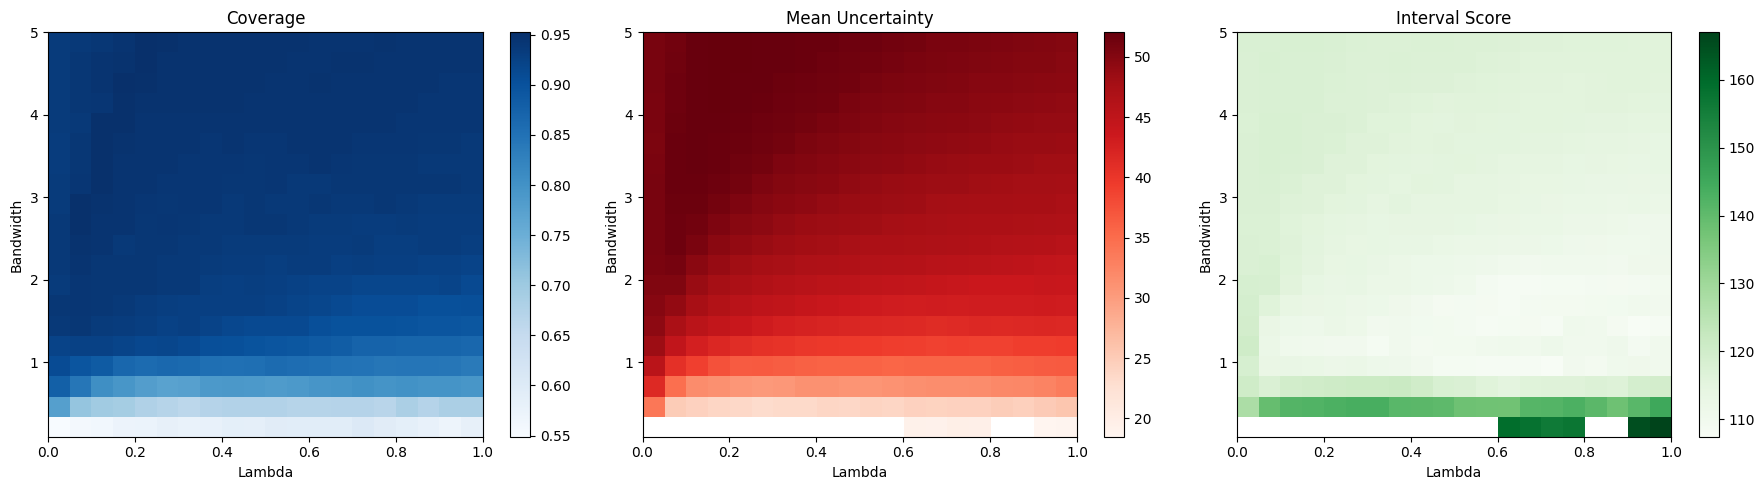

In [ ]:
bandwidth_list = np.linspace(0.1, 5.0, 20)
lambda_list = np.linspace(0, 1.0, 20)

coverage_grid, uncertainty_grid, interval_score_grid = bandwidth_lambda_grid_sweep(
    bandwidth_list=bandwidth_list,
    lambda_list=lambda_list,
    model_spatial=model_spatial,
    X_spatial_val=X_spatial_val,
    X_spatial_test=X_spatial_test,
    X_aspatial_val=X_aspatial_val,
    X_aspatial_test=X_aspatial_test,
    y_val=y_val,
    y_test=y_test,
    loc_val=loc_val,
    loc_test=loc_test,
    alpha=0.1
)


In [ ]:

def interval_score(y_true, lower, upper, alpha=0.1):
    width = upper - lower
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    return width + (2 / alpha) * (below + above)

def select_best_lambda_bandwidth(coverage_grid, score_grid, lambda_list, bandwidth_list, threshold=0.9):
    mask = coverage_grid >= threshold
    masked_score = np.where(mask, score_grid, np.inf)
    idx = np.unravel_index(np.argmin(masked_score), masked_score.shape)
    best_lambda = lambda_list[idx[1]]
    best_bandwidth = bandwidth_list[idx[0]]
    return best_lambda, best_bandwidth, masked_score[idx], idx

def bandwidth_lambda_grid_sweep(
    bandwidth_list,
    lambda_list,
    model_spatial,
    X_spatial_val,
    X_spatial_test,
    X_aspatial_val,
    X_aspatial_test,
    y_val,
    y_test,
    loc_val,
    loc_test,
    alpha=0.1,
    coverage_threshold=0.9
):
    coverage_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    uncertainty_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    interval_score_grid = np.zeros((len(bandwidth_list), len(lambda_list)))

    for i, bw in enumerate(bandwidth_list):
        for j, lam in enumerate(lambda_list):
            model = GeoSIMConformalSpatialRegression(
                predict_f=model_spatial.predict,
                miscoverage_level=alpha,
                bandwidth=bw,
                coord_calib=loc_val.values,
                coord_test=loc_test.values,
                X_calib=X_spatial_val,
                y_calib=y_val,
                X_test=X_spatial_test,
                y_test=y_test,
                X_calib_weight=X_aspatial_val,
                X_test_weight=X_aspatial_test,
                lambda_weight=lam
            )

            result = model.analyze()

            coverage_grid[i, j] = result.coverage_probability
            uncertainty_grid[i, j] = result.uncertainty

            lower = np.array(result.lower_bound)
            upper = np.array(result.upper_bound)
            y_true = np.array(y_test)

            score = interval_score(y_true, lower, upper, alpha=alpha)
            interval_score_grid[i, j] = np.mean(score)

    best_lambda, best_bw, best_score, idx = select_best_lambda_bandwidth(
        coverage_grid, interval_score_grid, lambda_list, bandwidth_list, threshold=coverage_threshold
    )
    best_coverage = coverage_grid[idx]
    best_uncertainty = uncertainty_grid[idx]

    # 可视化 heatmap with masking
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    im1 = axs[0].imshow(coverage_grid, origin='lower', aspect='auto', cmap='Blues',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[0].set_title('Coverage')
    axs[0].set_xlabel('Lambda')
    axs[0].set_ylabel('Bandwidth')
    fig.colorbar(im1, ax=axs[0])

    im2 = axs[1].imshow(uncertainty_grid, origin='lower', aspect='auto', cmap='Reds',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[1].set_title('Mean Uncertainty')
    axs[1].set_xlabel('Lambda')
    axs[1].set_ylabel('Bandwidth')
    fig.colorbar(im2, ax=axs[1])

    masked_score_grid = np.where(coverage_grid >= coverage_threshold, interval_score_grid, np.nan)
    im3 = axs[2].imshow(masked_score_grid, origin='lower', aspect='auto', cmap='Greens',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[2].set_title(f'Interval Score (valid if coverage ≥ {coverage_threshold:.2f})')
    axs[2].set_xlabel('Lambda')
    axs[2].set_ylabel('Bandwidth')
    fig.colorbar(im3, ax=axs[2])

    axs[2].scatter([best_lambda], [best_bw], color='black', label='Best (λ, bw)', marker='x')
    axs[2].legend()

    plt.tight_layout()
    plt.show()

    print(f"Best parameters (coverage ≥ {coverage_threshold}):")
    print(f"  Coverage        = {best_coverage:.3f}")
    print(f"  Lambda          = {best_lambda:.3f}")
    print(f"  Bandwidth       = {best_bw:.3f}")
    print(f"  Interval Score  = {best_score:.3f}")
    print(f"  Mean Interval   = {best_uncertainty:.3f}")

    return coverage_grid, uncertainty_grid, interval_score_grid


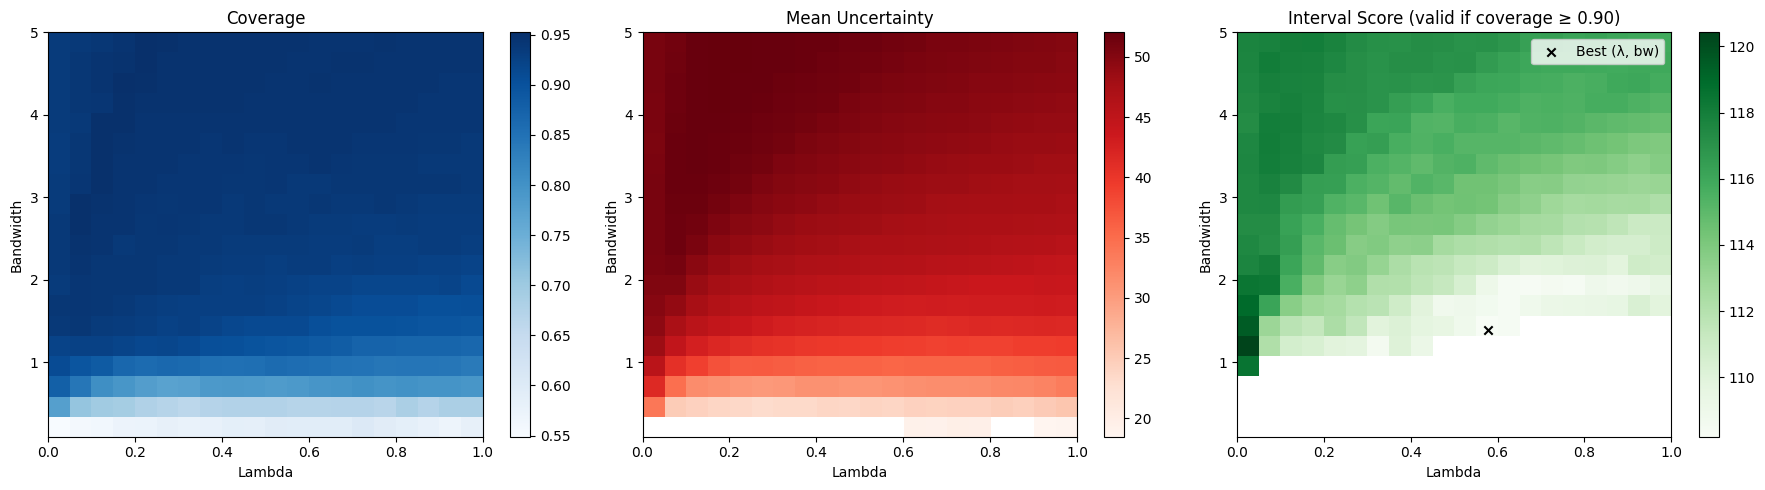

Best parameters (coverage ≥ 0.9):
  Coverage        = 0.912
  Lambda          = 0.579
  Bandwidth       = 1.389
  Interval Score  = 108.203
  Mean Interval   = 41.613


In [ ]:
coverage_grid, uncertainty_grid, interval_score_grid = bandwidth_lambda_grid_sweep(
    bandwidth_list=np.linspace(0.1, 5.0, 20),
    lambda_list=np.linspace(0, 1.0, 20),
    model_spatial=model_spatial,
    X_spatial_val=X_spatial_val,
    X_spatial_test=X_spatial_test,
    X_aspatial_val=X_aspatial_val,
    X_aspatial_test=X_aspatial_test,
    y_val=y_val,
    y_test=y_test,
    loc_val=loc_val,
    loc_test=loc_test,
    alpha=0.1,
    coverage_threshold=0.9
)


# GEOSIMCP——zhap


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from GeoSIMCPzhao import GeoSIMCPzhao

def interval_score(y_true, lower, upper, alpha=0.1, epsilon=1e-6):
    width = np.maximum(upper - lower, epsilon)
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    score = width + (2 / alpha) * (below + above)
    score = np.where(np.isnan(score), 0.0, score)
    return score

def select_best_lambda_bandwidth(coverage_grid, score_grid, lambda_list, bandwidth_list, threshold=0.9):
    mask = coverage_grid >= threshold
    masked_score = np.where(mask, score_grid, np.inf)
    idx = np.unravel_index(np.argmin(masked_score), masked_score.shape)
    best_lambda = lambda_list[idx[1]]
    best_bandwidth = bandwidth_list[idx[0]]
    return best_lambda, best_bandwidth, masked_score[idx], idx

def bandwidth_lambda_grid_sweep(
    bandwidth_list,
    lambda_list,
    model_spatial,
    X_spatial_val,
    X_spatial_test,
    X_aspatial_val,
    X_aspatial_test,
    y_val,
    y_test,
    loc_val,
    loc_test,
    alpha=0.1,
    coverage_threshold=0.9
):
    coverage_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    uncertainty_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    interval_score_grid = np.zeros((len(bandwidth_list), len(lambda_list)))

    for i, bw in enumerate(bandwidth_list):
        for j, lam in enumerate(lambda_list):
            model = GeoSIMCPzhao(
                predict_f=model_spatial.predict,
                miscoverage_level=alpha,
                bandwidth=bw,
                coord_calib=loc_val.values,
                coord_test=loc_test.values,
                X_calib=X_spatial_val,
                y_calib=y_val,
                X_test=X_spatial_test,
                y_test=y_test,
                X_calib_weight=X_aspatial_val,
                X_test_weight=X_aspatial_test,
                lambda_weight=lam
            )

            result = model.analyze()

            coverage_grid[i, j] = result.coverage_probability
            # Use robust mean for uncertainty
            if result.geo_uncertainty is not None:
                valid_uncertainty = np.array(result.geo_uncertainty)
                valid_uncertainty = valid_uncertainty[~np.isnan(valid_uncertainty)]
                uncertainty_grid[i, j] = np.mean(valid_uncertainty) if len(valid_uncertainty) > 0 else np.nan
            else:
                uncertainty_grid[i, j] = np.nan

            lower = np.array(result.lower_bound)
            upper = np.array(result.upper_bound)
            y_true = np.array(y_test)

            score = interval_score(y_true, lower, upper, alpha=alpha)
            score_filtered = score[~np.isnan(score)]
            interval_score_grid[i, j] = np.mean(score_filtered) if len(score_filtered) > 0 else np.nan

            if np.isnan(interval_score_grid[i, j]):
                print(f"[Warning] NaN interval score at λ={lam:.3f}, bw={bw:.3f}")

    best_lambda, best_bw, best_score, idx = select_best_lambda_bandwidth(
        coverage_grid, interval_score_grid, lambda_list, bandwidth_list, threshold=coverage_threshold
    )
    best_coverage = coverage_grid[idx]
    best_uncertainty = uncertainty_grid[idx]

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    im1 = axs[0].imshow(coverage_grid, origin='lower', aspect='auto', cmap='Blues',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[0].set_title('Coverage')
    axs[0].set_xlabel('Lambda')
    axs[0].set_ylabel('Bandwidth')
    fig.colorbar(im1, ax=axs[0])

    im2 = axs[1].imshow(uncertainty_grid, origin='lower', aspect='auto', cmap='Reds',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[1].set_title('Mean Uncertainty')
    axs[1].set_xlabel('Lambda')
    axs[1].set_ylabel('Bandwidth')
    fig.colorbar(im2, ax=axs[1])

    masked_score_grid = np.where(coverage_grid >= coverage_threshold, interval_score_grid, np.nan)
    im3 = axs[2].imshow(masked_score_grid, origin='lower', aspect='auto', cmap='Greens',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[2].set_title(f'Interval Score (valid if coverage ≥ {coverage_threshold:.2f})')
    axs[2].set_xlabel('Lambda')
    axs[2].set_ylabel('Bandwidth')
    fig.colorbar(im3, ax=axs[2])

    axs[2].scatter([best_lambda], [best_bw], color='black', label='Best (λ, bw)', marker='x')
    axs[2].legend()

    plt.tight_layout()
    plt.show()

    print(f"Best parameters (coverage ≥ {coverage_threshold}):")
    print(f"  Coverage        = {best_coverage:.3f}")
    print(f"  Lambda          = {best_lambda:.3f}")
    print(f"  Bandwidth       = {best_bw:.3f}")
    print(f"  Interval Score  = {best_score:.3f}")
    print(f"  Mean Interval   = {best_uncertainty:.3f}")

    return coverage_grid, uncertainty_grid, interval_score_grid


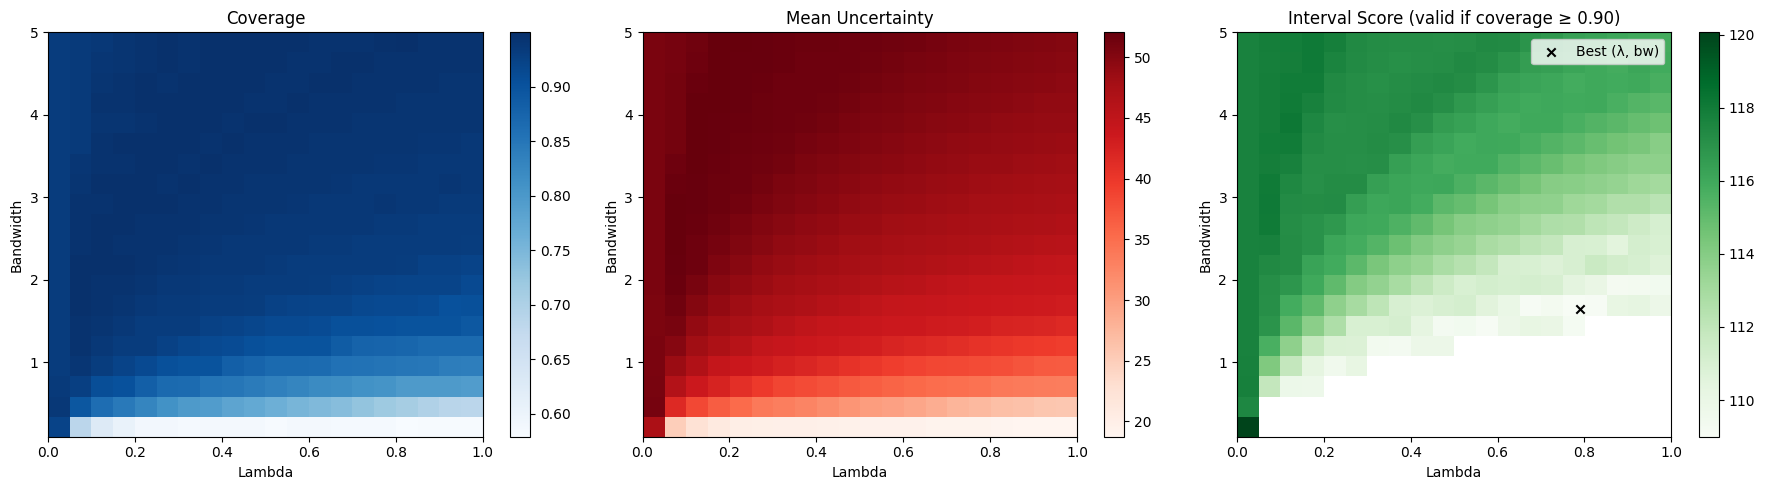

Best parameters (coverage ≥ 0.9):
  Coverage        = 0.912
  Lambda          = 0.789
  Bandwidth       = 1.647
  Interval Score  = 108.996
  Mean Interval   = 43.730


In [ ]:
coverage_grid, uncertainty_grid, interval_score_grid = bandwidth_lambda_grid_sweep(
    bandwidth_list=np.linspace(0.1, 5.0, 20),
    lambda_list=np.linspace(0, 1.0, 20),
    model_spatial=model_spatial,
    X_spatial_val=X_spatial_val,
    X_spatial_test=X_spatial_test,
    X_aspatial_val=X_aspatial_val,
    X_aspatial_test=X_aspatial_test,
    y_val=y_val,
    y_test=y_test,
    loc_val=loc_val,
    loc_test=loc_test,
    alpha=0.1,
    coverage_threshold=0.9
)